Train shape: (24000, 35)
Test shape: (6000, 35)

=== AVANT SMOTE ===
Classe 0 (non défaut): 18691
Classe 1 (défaut): 5309

=== APRÈS SMOTE ===
Classe 0 (non défaut): 18691
Classe 1 (défaut): 18691

=== Logistic Regression AVEC SMOTE ===
Matrice de confusion:
[[3127 1546]
 [ 491  836]]
Recall: 0.6300
ROC-AUC: 0.7182

=== Random Forest AVEC SMOTE ===
Matrice de confusion:
[[3740  933]
 [ 545  782]]
Recall: 0.5893
ROC-AUC: 0.7609

=== XGBoost AVEC SMOTE ===
Matrice de confusion:
[[4185  488]
 [ 737  590]]
Recall: 0.4446
ROC-AUC: 0.7602

=== COMPARAISON RECALL ===
                Modèle  Recall  Recall_smote
0  Logistic Regression  0.1767        0.6300
1        Decision Tree  0.3213           NaN
2        Random Forest  0.2641        0.5893
3              XGBoost  0.3092        0.4446

=== COMPARAISON ROC-AUC ===
                Modèle  ROC-AUC  ROC-AUC_smote
0  Logistic Regression   0.7194         0.7182
1        Decision Tree   0.7443            NaN
2        Random Forest   0.7646       

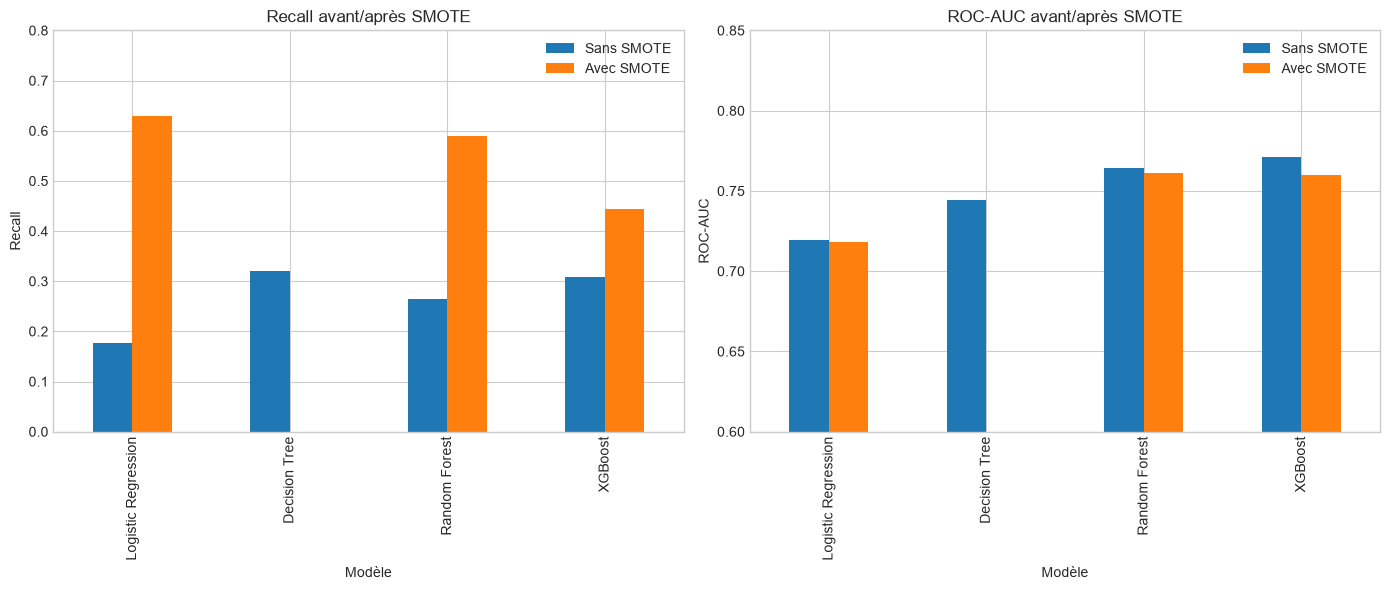


✅ Modèle XGBoost avec SMOTE sauvegardé !


In [3]:
# %% [markdown]
# # 05 - Model Improvement avec SMOTE
# ## Projet : AI Credit Risk Prediction Platform

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix)
from imblearn.over_sampling import SMOTE
import joblib

plt.style.use('seaborn-v0_8-whitegrid')

# Chargement
X = pd.read_csv('../data/processed/X_features.csv')
y = pd.read_csv('../data/processed/y_target.csv').values.ravel()

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train shape: {X_train_scaled.shape}")
print(f"Test shape: {X_test_scaled.shape}")

# %% [markdown]
# ### Application de SMOTE

# %%
print("\n=== AVANT SMOTE ===")
print(f"Classe 0 (non défaut): {sum(y_train==0)}")
print(f"Classe 1 (défaut): {sum(y_train==1)}")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("\n=== APRÈS SMOTE ===")
print(f"Classe 0 (non défaut): {sum(y_train_smote==0)}")
print(f"Classe 1 (défaut): {sum(y_train_smote==1)}")

# %% [markdown]
# ### Entraînement des modèles avec SMOTE

# %%
models = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, 
                             use_label_encoder=False, eval_metric='logloss')
}

results = []

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"=== {name} AVEC SMOTE ===")
    
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    results.append({
        'Modèle': f'{name} (SMOTE)',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })
    
    cm = confusion_matrix(y_test, y_pred)
    print(f"Matrice de confusion:\n{cm}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

# %% [markdown]
# ### Comparaison avant/après SMOTE

# %%
# Résultats sans SMOTE (de votre précédent notebook)
results_no_smote = pd.DataFrame([
    {'Modèle': 'Logistic Regression', 'Recall': 0.1767, 'ROC-AUC': 0.7194},
    {'Modèle': 'Decision Tree', 'Recall': 0.3213, 'ROC-AUC': 0.7443},
    {'Modèle': 'Random Forest', 'Recall': 0.2641, 'ROC-AUC': 0.7646},
    {'Modèle': 'XGBoost', 'Recall': 0.3092, 'ROC-AUC': 0.7709}
])

# Résultats avec SMOTE
results_smote = pd.DataFrame([
    {'Modèle': 'Logistic Regression', 'Recall_smote': 0.6300, 'ROC-AUC_smote': 0.7182},
    {'Modèle': 'Random Forest', 'Recall_smote': 0.5893, 'ROC-AUC_smote': 0.7609},
    {'Modèle': 'XGBoost', 'Recall_smote': 0.4446, 'ROC-AUC_smote': 0.7602}
])

# Fusion
comparison = results_no_smote.merge(results_smote, on='Modèle', how='left')

print("\n=== COMPARAISON RECALL ===")
print(comparison[['Modèle', 'Recall', 'Recall_smote']])

print("\n=== COMPARAISON ROC-AUC ===")
print(comparison[['Modèle', 'ROC-AUC', 'ROC-AUC_smote']])

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Recall
comparison.plot(kind='bar', x='Modèle', y=['Recall', 'Recall_smote'], ax=axes[0])
axes[0].set_title('Recall avant/après SMOTE')
axes[0].set_ylabel('Recall')
axes[0].set_ylim(0, 0.8)
axes[0].legend(['Sans SMOTE', 'Avec SMOTE'])

# ROC-AUC
comparison.plot(kind='bar', x='Modèle', y=['ROC-AUC', 'ROC-AUC_smote'], ax=axes[1])
axes[1].set_title('ROC-AUC avant/après SMOTE')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_ylim(0.6, 0.85)
axes[1].legend(['Sans SMOTE', 'Avec SMOTE'])

plt.tight_layout()
plt.savefig('../data/processed/smote_comparison.png', dpi=150)
plt.show()

# Sauvegarde du meilleur modèle avec SMOTE
best_smote_model = models['XGBoost']
joblib.dump(best_smote_model, '../models/xgboost_smote.pkl')
print("\n✅ Modèle XGBoost avec SMOTE sauvegardé !")